In [5]:
import re
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from tqdm.auto import tqdm
from clearml import Task, Logger


In [2]:
# Конфигурация
config = {
    "project_name": "WikiText_Global_Search",
    "n_epochs": 15,
    "weight_decay": 1e-5,
    "hidden_dim": 512,
    "embedding_dim": 256,
    "batch_size": 64,
    "seq_len": 32,
    "num_layers": 2,
    "lr": 0.002,
    "dropout": 0.1,
    "min_word_freq": 5,
    "max_norm": 1,
    "max_texts_count": 0 # this params exists for local testing

}

In [3]:
# Этап 0. Подготовка - done
# Есть ячейка с импортами и фиксированным seed = 42. - done
# Датасет WikiText-2 загружен. - done

np.random.seed(42)
torch.manual_seed(42)
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

Train size: 36718
Validation size: 3760
Test size: 4358

Статистика по количеству слов в тексте:
Среднее: 55.88
Медиана: 8.00
5-й перцентиль: 0.00
95-й перцентиль: 213.15


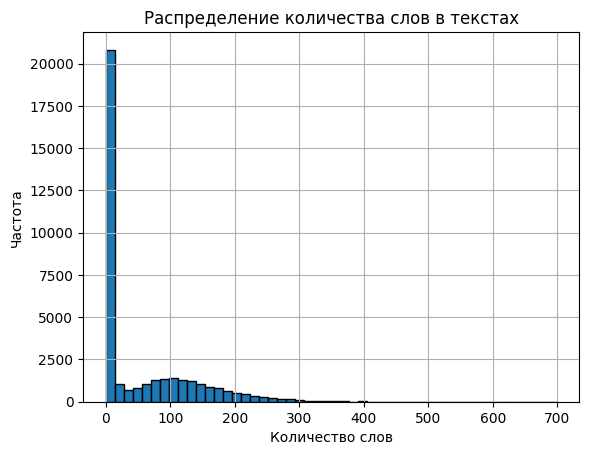


Статистика по количеству слов в тексте:
Среднее: 118.69
Медиана: 108.00
5-й перцентиль: 44.00
95-й перцентиль: 229.00


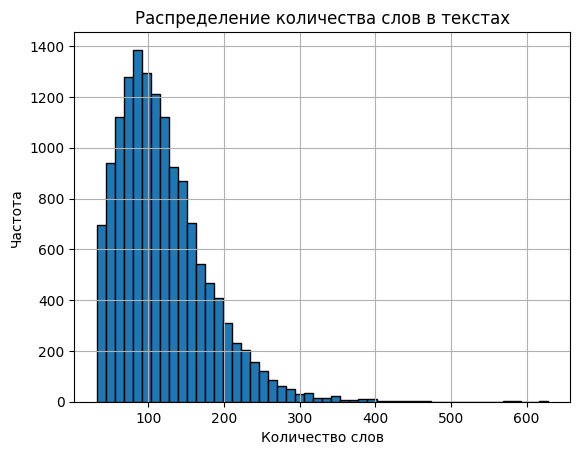

Количество слов в словаре:  20428
Исходный текст:  senj no valkyria 3 unrecorded ch
Токенизированный:  [1, 2, 3, 4, 0, 7843]
Декодированный обратно в слова: ['senj', 'no', 'valkyria', '3', '<unk>', 'ch']


TypeError: WikiDataset.__init__() got multiple values for argument 'seq_len'

In [6]:
# Этап 1. Данные - done
# Проведён разведочный анализ (примеры текстов, статистики, визуализации). - done
# Реализована пословная токенизация с построением словаря. - done
# Сформированы последовательности для обучения (вход сдвинут на 1 токен относительно таргета). - done
# Созданы torch.Dataset и DataLoader для train/val/test. - done
# Код этапа рабочий, ошибок не вызывает. - done


# Проведён разведочный анализ (примеры текстов, статистики, визуализации).
train_data = dataset['train']
val_data = dataset['validation']
test_data = dataset['test']

print(f"Train size: {len(train_data)}")
print(f"Validation size: {len(val_data)}")
print(f"Test size: {len(test_data)}")

texts = train_data["text"]
word_counts = [len(text.split()) for text in texts]

# Добавим две функции: чистку текста и построение графиков статистики
def clean_text(texts, min_seq_len):
    res = []
    for text in texts:
        text = text.lower()  # к нижнему регистру
        text = re.sub(r"[^a-z0-9 ]+", " ", text)  # оставить только буквы и цифры
        text = re.sub(r"\s+", " ", text).strip()  # убрать дублирующиеся пробелы
        if len(text.split()) >= min_seq_len:
            res.append(text)
    return res

def show_stat(texts):
    word_counts = [len(text.split()) for text in texts]
    print("\nСтатистика по количеству слов в тексте:")
    print(f"Среднее: {np.mean(word_counts):.2f}")
    print(f"Медиана: {np.median(word_counts):.2f}")
    print(f"5-й перцентиль: {np.percentile(word_counts, 5):.2f}")
    print(f"95-й перцентиль: {np.percentile(word_counts, 95):.2f}")


    # Гистограмма распределения длины
    plt.hist(word_counts, bins=50, edgecolor='black')
    plt.title("Распределение количества слов в текстах")
    plt.xlabel("Количество слов")
    plt.ylabel("Частота")
    plt.grid(True)
    plt.show() 


show_stat(texts)

# Вывод: очень много пустых текстов, нужна очистка и затем повторный анализ.
cleaned_texts = clean_text(texts, config["seq_len"])
show_stat(cleaned_texts)


# Реализована пословная токенизация с построением словаря.
class WikiTokenizer:
    def __init__(self, min_freq=5):
        self.itos = {0: "<unk>"}
        self.stoi = {"<unk>": 0}
        self.min_freq = min_freq

    def build_vocabulary(self, texts):
        freqs = Counter()
        for t in texts: 
            freqs.update(re.findall(r"[\w']+", t.lower()))
        idx = 1
        for word, freq in freqs.items():
            if freq >= self.min_freq:
                self.stoi[word] = idx
                self.itos[idx] = word
                idx += 1
    
    def encode(self, text):
        return [self.stoi.get(w, 0) for w in re.findall(r"[\w']+", text.lower())]
    
    def decode(self, tokens):
        return [self.itos.get(int(t), "<unk>") for t in tokens]

    def __len__(self):
        return len(self.itos)

# Сформированы последовательности для обучения (вход сдвинут на 1 токен относительно таргета).
class WikiDataset(Dataset):
    def __init__(self, texts, tokenizer, seq_len):
        self.samples = []
        for t in texts:
            tokens = tokenizer.encode(t)
            for i in range(0, len(tokens) - seq_len, seq_len):
                chunk = torch.tensor(tokens[i:i+seq_len], dtype=torch.long)
                if len(chunk) == seq_len:
                    self.samples.append(chunk)

    def __len__(self): 
        return len(self.samples)

    def __getitem__(self, i): 
        return self.samples[i][:-1], self.samples[i][1:]

tokenizer = WikiTokenizer(min_freq=config["min_word_freq"])
tokenizer.build_vocabulary(cleaned_texts)
print("Количество слов в словаре: ", len(tokenizer))

# Проверим, что токенайзер работает корректно
sample = cleaned_texts[0][:config["seq_len"]]
encoded_sample = tokenizer.encode(sample)
decoded_sample = tokenizer.decode(encoded_sample)

print("Исходный текст: ", sample)
print("Токенизированный: ", encoded_sample)
print("Декодированный обратно в слова:", decoded_sample)

# Созданы torch.Dataset и DataLoader для train/val/test.
if config["max_texts_count"] > 0:
    cleaned_texts = cleaned_texts[:config["max_texts_count"]]
    val_data = val_data.select(range(int(config["max_texts_count"]*0.05)))

train_dataset = WikiDataset(cleaned_texts, tokenizer, seq_len=config["seq_len"])
val_dataset = WikiDataset(clean_text(val_data["text"], config["seq_len"]), tokenizer, seq_len=config["seq_len"])
test_dataset = WikiDataset(test_data, config["seq_len"], tokenizer, seq_len=config["seq_len"])

train_dataloader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=config["batch_size"])
test_dataloader = DataLoader(test_dataset, batch_size=config["batch_size"])


# Проверяем, что __getitem__ возвращает корректные данные
x, y = train_dataset.__getitem__(0)
print(tokenizer.decode(x))
print(tokenizer.decode(y))

# Код этапа рабочий, ошибок не вызывает. - Done.
print("Этап 1 - done")



In [ ]:
# Этап 2. LSTM-модель - done
# Реализован класс модели (Embedding + LSTM + Linear). - done
# Написан цикл обучения с выводом loss и perplexity. - done
# Применён gradient clipping. - done
# Модель обучена, val perplexity снижается. - done
# Построены графики обучения. = done
# Код этапа рабочий, ошибок не вызывает. - done

import time

# Реализован класс модели (Embedding + LSTM + Linear).
class RNNModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, rnn_type='LSTM', n_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, batch_first=True, dropout=dropout)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(emb_dim, hid_dim, n_layers, batch_first=True, dropout=dropout)
        else:
            raise Exception("Unknown rnn_type")
        self.fc = nn.Linear(hid_dim, vocab_size)
    
    def forward(self, x):
        out, _ = self.rnn(self.embedding(x))
        return self.fc(out)


class RNNTrainer:
    def __init__(self, model, tokenizer, train_loader, val_loader, config, task=None):
        self.tokenizer = tokenizer
        self.vocab_size = len(tokenizer)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.config = config
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model
        self.model.to(self.device)
        
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
        self.criterion = nn.CrossEntropyLoss()
        if task:
            self.task = task
            self.logger = Logger.current_logger()
        else:
            self.task = None

        # Хранилище метрик
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'val_ppl': []
        }
        self.total_training_time = 0

    # Написан цикл обучения с выводом loss и perplexity.
    def train(self):
        best_loss = float('inf')
        patience_counter = 0

        start_training_time = time.time()

        for epoch in range(self.config["n_epochs"]):
            self.model.train()
            total_loss = 0
            for x, y in tqdm(self.train_loader, desc=f"Epoch {epoch}"):
                x, y = x.to(self.device), y.to(self.device)
                self.optimizer.zero_grad()
                logits = self.model(x)
                loss = self.criterion(logits.view(-1, self.vocab_size), y.view(-1))
                loss.backward()
                # Применён gradient clipping.
                nn.utils.clip_grad_norm_(self.model.parameters(), self.config["max_norm"])
                self.optimizer.step()
                total_loss += loss.item()
            avg_train_loss = total_loss / len(self.train_loader)
            # Валидация
            avg_val_loss, val_ppl, _ = self.evaluate()
            
            # Сохранение истории
            self.history['train_loss'].append(avg_train_loss)
            self.history['val_loss'].append(avg_val_loss)
            self.history['val_ppl'].append(val_ppl)
            
            # Визуализация
            self.plot_history()
            print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} |Val PPL: {val_ppl:.2f}")

            # Early Stopping
            if avg_val_loss < best_loss:
                best_loss = avg_val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= 2:
                    print("Early Stopping triggered!")
                    break
            
        
        end_training_time = time.time()
        self.total_training_time = end_training_time - start_training_time

        if self.task:
            self.task.close()

        self.avg_val_loss = avg_val_loss
        self.val_ppl = val_ppl
        

    def evaluate(self):
        self.model.eval()
        v_loss = 0
        start_time = time.time()
        with torch.no_grad():
            for x, y in self.val_loader:
                x, y = x.to(self.device), y.to(self.device)
                out = self.model(x)
                v_loss += self.criterion(out.view(-1, self.vocab_size), y.view(-1)).item()
        end_time = time.time()
        total_time = end_time - start_time
        avg_loss = v_loss / len(self.val_loader)
        return avg_loss, np.exp(avg_loss), total_time 
    
    def check_predictions(self, num_examples=2):
        self.model.eval()
        with torch.no_grad():
            x, y = next(iter(self.val_loader))
            outputs = self.model.forward(x)
            predictions = outputs.argmax(dim=-1)
            
            print("\n" + "-"*30 + " СРЕЗ ПРЕДСКАЗАНИЙ " + "-"*30)
            for i in range(num_examples):
                print(f"\n[Пример {i+1}]")
                print(f"Контекст (X):  {self.tokenizer.decode(x[i])}")
                print(f"Ожидалось (Y): {self.tokenizer.decode(y[i])}")
                print(f"Модель выдала: {self.tokenizer.decode(predictions[i])}")

    def plot_history(self):
        epochs = range(1, len(self.history['train_loss']) + 1)
        
        plt.figure(figsize=(12, 5))
        
        # График Loss
        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.history['train_loss'], label='Train Loss', marker='o')
        plt.plot(epochs, self.history['val_loss'], label='Val Loss', marker='o')
        plt.title('Loss over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        
        # График Perplexity
        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.history['val_ppl'], label='Val PPL', color='green', marker='s')
        plt.title('Perplexity over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('PPL')
        plt.legend()
        plt.grid(True)
        plt.show()


lstm_model = RNNModel(
    len(tokenizer), config["embedding_dim"], config["hidden_dim"],
    "LSTM", config["num_layers"], config["dropout"]
)
        
lstm_trainer = RNNTrainer(lstm_model, tokenizer, train_dataloader, val_dataloader, config)
lstm_trainer.train()


In [ ]:
# Этап 3. Эксперимент GRU vs LSTM
# GRU-модель реализована и обучена.
# Проведено сравнение по perplexity, числу параметров и скорости.
# Сделаны выводы по эксперименту.


gru_model = RNNModel(
    len(tokenizer), config["embedding_dim"], config["hidden_dim"],
    "GRU", config["num_layers"], config["dropout"]
)
# уменьшаем lr, так как GRU быстрее переобучается на тех же параметрах
config["lr"] = 0.001
gru_trainer = RNNTrainer(gru_model, tokenizer, train_dataloader, val_dataloader, config)
# GRU-модель реализована и обучена.
gru_trainer.train()


In [ ]:

def get_model_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_model_stat(model_trainer):
    model = model_trainer.model
    print("Model:", model)
    print("Число параметров:", sum(p.numel() for p in model.parameters() if p.requires_grad))
    print("Скорость обучения:", model_trainer.total_training_time)
    print("Скорость предсказания:", model_trainer.total_training_time)
    print("Val perplexity:", model_trainer.val_ppl)

# Проведено сравнение по perplexity, числу параметров и скорости.
get_model_stat(lstm_trainer)
get_model_stat(gru_trainer)

# Сделаны выводы по эксперименту.
# ВЫВОД: GRU быстрее и легче 

In [ ]:
# Этап 4. distilgpt2 - done
# Модель загружена, метрика perplexity вычислена на тестовой выборке. - done
# Показаны примеры предсказаний. - done

from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

model_name = "distilgpt2"
tokenizer_gpt = GPT2Tokenizer.from_pretrained(model_name)
model_gpt = GPT2LMHeadModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_gpt.to(device)
model_gpt.eval() # Переводим в режим оценки

# У GPT-2 нет pad_token по умолчанию, добавим его для корректной работы
tokenizer_gpt.pad_token = tokenizer_gpt.eos_token

def calculate_gpt2_perplexity(test_texts, model, tokenizer, batch_size=16):
    total_loss = 0
    total_length = 0
    
    with torch.no_grad():
        for i in range(0, len(test_texts), batch_size):
            batch = test_texts[i : i + batch_size]
            # Токенизация с обрезкой и дополнением до фиксированной длины
            inputs = tokenizer(batch, return_tensors="pt", truncation=True, 
                               padding=True, max_length=512).to(device)
            
            # В Transformers, если передать labels=input_ids, модель сама посчитает Loss
            outputs = model(**inputs, labels=inputs["input_ids"])
            loss = outputs.loss
            
            total_loss += loss.item() * inputs["input_ids"].size(0)
            total_length += inputs["input_ids"].size(0)
            
    avg_loss = total_loss / total_length
    perplexity = torch.exp(torch.tensor(avg_loss))
    return avg_loss, perplexity.item()

def generate_text(prompt, model, tokenizer, max_length=50):
    input_ids = tokenizer.encode(prompt, return_tensors="pt", max_length=512, truncation=True)
    summary_ids = model.generate(input_ids, max_length=max_length, min_length=10, length_penalty=2.0, num_beams=4, early_stopping=True)

    # Декодируем результат
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

# Модель загружена, метрика perplexity вычислена на тестовой выборке. - done
test_loss_gpt, test_ppl_gpt = calculate_gpt2_perplexity(test_dataloader, model_gpt, tokenizer_gpt)
print(f"DistilGPT2 Test Loss: {test_loss_gpt:.4f}")
print(f"DistilGPT2 Test Perplexity: {test_ppl_gpt:.2f}")

# Показаны примеры предсказаний. - done
prompts = [
    "The capital of France is",
    "In a galaxy far far away",
    "Deep learning is a subset of"
]

for p in prompts:
    print(f"Prompt: {p}")
    print(f"Generated: {generate_text(p, model_gpt, tokenizer_gpt, max_length=5)}")
    print("-" * 30)
    


In [ ]:


def predict_next_word_rnn(text, model, tokenizer, device="cuda"):
    model.eval()
    inputs = tokenizer.encode(text, return_tensors="pt").to(device)
    
    start_time = time.time() # Старт замера
    with torch.no_grad():
        logits = model(inputs)
        last_token_logits = logits[0, -1, :]
        predicted_index = torch.argmax(last_token_logits).item()
    end_time = time.time() # Конец замера
    
    latency = end_time - start_time
    word = tokenizer.decode([predicted_index])
    return word, latency


def predict_next_word_gpt(text, model, tokenizer, device="cuda"):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt").to(device)
    
    start_time = time.time() # Старт замера
    with torch.no_grad():
        outputs = model(**inputs)
        last_token_logits = outputs.logits[0, -1, :]
        predicted_index = torch.argmax(last_token_logits).item()
    end_time = time.time() # Конец замера
    
    latency = end_time - start_time
    word = tokenizer.decode([predicted_index])
    return word, latency


